In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import io
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['axes.unicode_minus'] = False
print("라이브러리 로드 완료")

라이브러리 로드 완료


In [2]:
import glob
import os

folder = './'

files = glob.glob(folder + '*.csv')
print("찾은 파일 목록:")
for f in files:
    print(os.path.basename(f))

찾은 파일 목록:
rn_20260417161502.csv
ta_20260417161448.csv
서울특별시 공공자전거 이용정보(월별)_22.01.csv
서울특별시 공공자전거 이용정보(월별)_22.02.csv
서울특별시 공공자전거 이용정보(월별)_22.03.csv
서울특별시 공공자전거 이용정보(월별)_22.04.csv
서울특별시 공공자전거 이용정보(월별)_22.05.csv
서울특별시 공공자전거 이용정보(월별)_22.06.csv
서울특별시 공공자전거 이용정보(월별)_22.07_22.12.csv
서울특별시 공공자전거 이용정보(월별)_23.1-6.csv
서울특별시 공공자전거 이용정보(월별)_24.1-6.csv
서울특별시 공공자전거 이용정보(월별)_24.7-12.csv
서울특별시 공공자전거 이용정보(월별)_25.1-6.csv
서울특별시 공공자전거 이용정보(월별)_25.7-12.csv
서울특별시_공공자전거_이용정보(월별)_23.7-12.csv


In [3]:
dfs = []
for f in files:
    try:
        df = pd.read_csv(f, encoding='cp949')
        if '대여년월' in df.columns:
            df = df.rename(columns={'대여년월': '대여일자'})
        if '이용거리(M)' in df.columns:
            df = df.rename(columns={'이용거리(M)': '이동거리(M)'})
        if '이용건수' in df.columns:
            dfs.append(df)
    except:
        pass

combined = pd.concat(dfs, ignore_index=True)
combined = combined[['대여일자','이용건수']].dropna(subset=['대여일자'])

def normalize_date(val):
    val = str(val).strip()
    if '-' in val:
        return val.replace('-','')
    return str(val)[:6]

combined['연월'] = combined['대여일자'].apply(normalize_date)
monthly = combined.groupby('연월')['이용건수'].sum().reset_index()
monthly = monthly.sort_values('연월').reset_index(drop=True)

print(f"총 {len(monthly)}개월 데이터 로드 완료")
print(monthly.head())

총 48개월 데이터 로드 완료
       연월     이용건수
0  202201  1419866
1  202202  1349352
2  202203  2423766
3  202204  3990507
4  202205  4962837


In [4]:
ta_file = [f for f in files if 'ta_' in f][0]
with open(ta_file, 'rb') as f:
    raw = f.read().decode('cp949', errors='replace')
lines = raw.split('\n')
data_lines = [l.strip() for l in lines if l.strip().startswith('2')]
ta = pd.read_csv(io.StringIO('\n'.join(data_lines)), header=None,
                  names=['년월','지점','평균기온','평균최저기온','평균최고기온'])
ta['연월'] = ta['년월'].str.replace('-','')
ta = ta[['연월','평균기온']].copy()
ta['평균기온'] = pd.to_numeric(ta['평균기온'], errors='coerce')

rn_file = [f for f in files if 'rn_' in f][0]
with open(rn_file, 'rb') as f:
    raw = f.read().decode('cp949', errors='replace')
lines = raw.split('\n')
data_lines = [l.strip() for l in lines if l.strip().startswith('2')]
rn = pd.read_csv(io.StringIO('\n'.join(data_lines)), header=None,
                  names=['년월','지점','강수량'])
rn['연월'] = rn['년월'].str.replace('-','')
rn = rn[['연월','강수량']].copy()
rn['강수량'] = pd.to_numeric(rn['강수량'], errors='coerce')

print(f"기온 데이터: {len(ta)}개월")
print(f"강수량 데이터: {len(rn)}개월")

기온 데이터: 30개월
강수량 데이터: 30개월


In [5]:
df = monthly.merge(ta, on='연월', how='inner')
df = df.merge(rn, on='연월', how='inner')
df['년'] = df['연월'].str[:4]
df['월'] = df['연월'].str[4:].astype(int)
df = df.dropna()

print(f"최종 분석 데이터: {len(df)}개월")
print(f"분석 기간: {df['연월'].min()} ~ {df['연월'].max()}")
print()
print(df[['연월','이용건수','평균기온','강수량']].to_string())

최종 분석 데이터: 30개월
분석 기간: 202201 ~ 202406

        연월     이용건수  평균기온    강수량
0   202201  1419866  -2.2    5.5
1   202202  1349352  -1.1    4.7
2   202203  2423766   7.7  102.6
3   202204  3990507  14.8   20.4
4   202205  4962837  19.1    7.5
5   202206  4256692  23.3  393.8
6   202207  4101123  27.3  252.3
7   202208  3620583  25.7  564.8
8   202209  4760527  22.4  201.5
9   202210  4470255  14.6  124.1
10  202211  3838549  10.0   84.5
11  202212  1756699  -2.8   13.6
12  202301  1571353  -1.5   47.9
13  202302  2231490   2.3    1.0
14  202303  3885509   9.8   10.5
15  202304  4082065  13.8   96.9
16  202305  4952804  19.5  155.6
17  202306  4933533  23.4  195.6
18  202307  3931912  26.7  459.9
19  202308  3935440  27.2  298.1
20  202309  4548991  23.7  134.5
21  202310  5293193  15.8   31.0
22  202311  3433933   6.8   81.9
23  202312  2104442   1.1   85.9
24  202401  1983350  -0.5   18.9
25  202402  2031705   3.8   74.7
26  202403  3151221   7.0   29.9
27  202404  4599904  16.3   33.2
28 

In [6]:
corr_temp = df['이용건수'].corr(df['평균기온'])
corr_rain = df['이용건수'].corr(df['강수량'])

print("=== 상관관계 분석 결과 ===")
print(f"기온 - 이용건수 상관계수: {corr_temp:.3f}")
print(f"강수량 - 이용건수 상관계수: {corr_rain:.3f}")
print()
print(f"월평균 이용건수: {df['이용건수'].mean():,.0f}건")
print(f"최대 이용건수: {df['이용건수'].max():,.0f}건 ({df.loc[df['이용건수'].idxmax(),'연월']})")
print(f"최소 이용건수: {df['이용건수'].min():,.0f}건 ({df.loc[df['이용건수'].idxmin(),'연월']})")

=== 상관관계 분석 결과 ===
기온 - 이용건수 상관계수: 0.843
강수량 - 이용건수 상관계수: 0.309

월평균 이용건수: 3,575,620건
최대 이용건수: 5,293,193건 (202310)
최소 이용건수: 1,349,352건 (202202)


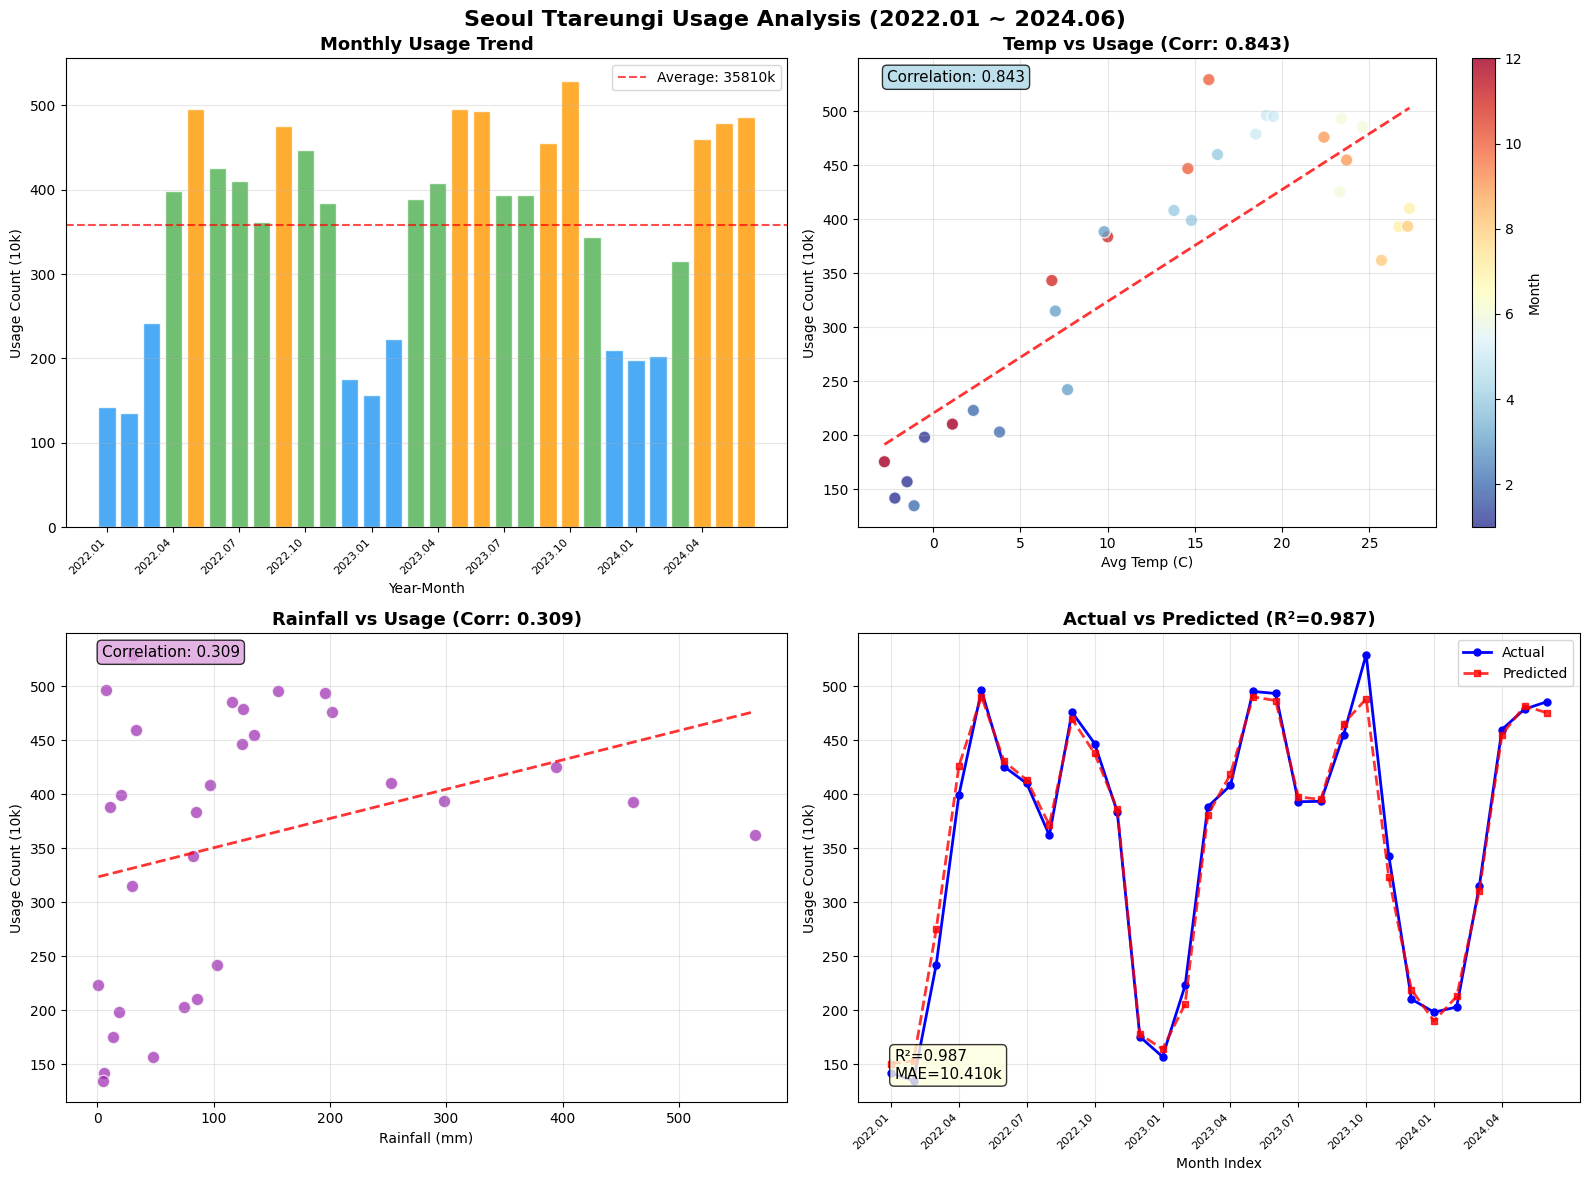

R²: 0.987
MAE: 103,964건


In [7]:
x_labels = df['연월'].apply(lambda x: x[:4]+'.'+x[4:])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Seoul Ttareungi Usage Analysis (2022.01 ~ 2024.06)',
             fontsize=16, fontweight='bold')

ax1 = axes[0, 0]
colors = ['#2196F3' if y < 3000000 else '#4CAF50' if y < 4500000 else '#FF9800'
          for y in df['이용건수']]
ax1.bar(range(len(df)), df['이용건수']/10000, color=colors, alpha=0.8, edgecolor='white')
ax1.set_title('Monthly Usage Trend', fontsize=13, fontweight='bold')
ax1.set_xlabel('Year-Month')
ax1.set_ylabel('Usage Count (10k)')
ax1.set_xticks(range(0, len(df), 3))
ax1.set_xticklabels(x_labels[::3], rotation=45, ha='right', fontsize=8)
ax1.axhline(y=df['이용건수'].mean()/10000, color='red', linestyle='--',
            alpha=0.7, label=f'Average: {df["이용건수"].mean()/10000:.0f}10k')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[0, 1]
scatter = ax2.scatter(df['평균기온'], df['이용건수']/10000,
                      c=df['월'], cmap='RdYlBu_r', s=80, alpha=0.8, edgecolors='white')
z = np.polyfit(df['평균기온'], df['이용건수']/10000, 1)
p = np.poly1d(z)
x_line = np.linspace(df['평균기온'].min(), df['평균기온'].max(), 100)
ax2.plot(x_line, p(x_line), 'r--', alpha=0.8, linewidth=2)
ax2.set_title(f'Temp vs Usage (Corr: {corr_temp:.3f})', fontsize=13, fontweight='bold')
ax2.set_xlabel('Avg Temp (C)')
ax2.set_ylabel('Usage Count (10k)')
plt.colorbar(scatter, ax=ax2, label='Month')
ax2.grid(alpha=0.3)
ax2.text(0.05, 0.95, f'Correlation: {corr_temp:.3f}', transform=ax2.transAxes,
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8), fontsize=11)

ax3 = axes[1, 0]
ax3.scatter(df['강수량'], df['이용건수']/10000, c='#9C27B0', s=80, alpha=0.7, edgecolors='white')
z2 = np.polyfit(df['강수량'], df['이용건수']/10000, 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(df['강수량'].min(), df['강수량'].max(), 100)
ax3.plot(x_line2, p2(x_line2), 'r--', alpha=0.8, linewidth=2)
ax3.set_title(f'Rainfall vs Usage (Corr: {corr_rain:.3f})', fontsize=13, fontweight='bold')
ax3.set_xlabel('Rainfall (mm)')
ax3.set_ylabel('Usage Count (10k)')
ax3.grid(alpha=0.3)
ax3.text(0.05, 0.95, f'Correlation: {corr_rain:.3f}', transform=ax3.transAxes,
         bbox=dict(boxstyle='round', facecolor='plum', alpha=0.8), fontsize=11)

X = df[['평균기온','강수량','월']]
y = df['이용건수']
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)

ax4 = axes[1, 1]
ax4.plot(range(len(df)), df['이용건수']/10000, 'b-o', label='Actual', markersize=5, linewidth=2)
ax4.plot(range(len(df)), y_pred/10000, 'r--s', label='Predicted', markersize=5, linewidth=2, alpha=0.8)
ax4.set_title(f'Actual vs Predicted (R²={r2:.3f})', fontsize=13, fontweight='bold')
ax4.set_xlabel('Month Index')
ax4.set_ylabel('Usage Count (10k)')
ax4.set_xticks(range(0, len(df), 3))
ax4.set_xticklabels(x_labels[::3], rotation=45, ha='right', fontsize=8)
ax4.legend()
ax4.grid(alpha=0.3)
ax4.text(0.05, 0.05, f'R²={r2:.3f}\nMAE={mae/10000:.1f}10k',
         transform=ax4.transAxes,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8), fontsize=11)

plt.tight_layout()
plt.savefig('ttareungi_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"R²: {r2:.3f}")
print(f"MAE: {mae:,.0f}건")

In [8]:
print("=" * 50)
print("서울 따릉이 이용량 분석 최종 결과")
print("=" * 50)
print(f"분석 기간: 2022.01 ~ 2024.06 (30개월)")
print(f"분석 데이터: 따릉이 이용정보 + 기상청 기온/강수량")
print()
print("[상관관계 분석]")
print(f"기온 - 이용건수 상관계수: {corr_temp:.3f} (매우 강한 양의 상관)")
print(f"강수량 - 이용건수 상관계수: {corr_rain:.3f} (약한 상관)")
print()
print("[예측 모델 성능]")
print(f"모델: RandomForest Regressor")
print(f"R²: {r2:.3f}")
print(f"MAE: {mae:,.0f}건")
print()
print("[핵심 인사이트]")
print("1. 기온이 1°C 상승할수록 따릉이 이용량 증가")
print("2. 강수량보다 기온이 이용량에 훨씬 강한 영향")
print("3. 매년 10월이 최대 이용 시즌 (선선한 날씨)")
print("4. 겨울(1~2월) 이용량은 가을 대비 약 4배 차이")
print()
print("[한계점]")
print("1. 기상 데이터가 2024.06까지만 확보됨")
print("2. 미세먼지, 공휴일 등 추가 변수 미반영")
print("3. 대여소별 지역적 특성 미분석")

서울 따릉이 이용량 분석 최종 결과
분석 기간: 2022.01 ~ 2024.06 (30개월)
분석 데이터: 따릉이 이용정보 + 기상청 기온/강수량

[상관관계 분석]
기온 - 이용건수 상관계수: 0.843 (매우 강한 양의 상관)
강수량 - 이용건수 상관계수: 0.309 (약한 상관)

[예측 모델 성능]
모델: RandomForest Regressor
R²: 0.987
MAE: 103,964건

[핵심 인사이트]
1. 기온이 1°C 상승할수록 따릉이 이용량 증가
2. 강수량보다 기온이 이용량에 훨씬 강한 영향
3. 매년 10월이 최대 이용 시즌 (선선한 날씨)
4. 겨울(1~2월) 이용량은 가을 대비 약 4배 차이

[한계점]
1. 기상 데이터가 2024.06까지만 확보됨
2. 미세먼지, 공휴일 등 추가 변수 미반영
3. 대여소별 지역적 특성 미분석
